# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
## M2 Assignment-1 Notebook: Model Building using PyTorch

*(This notebook was previously released during Module 2. It is reused here to provide a quick recap of how to train a model using PyTorch.)*

## Learning Objectives

At the end of the experiment, you will be able to

* load and visualize the MNIST dataset
* understand & build different components of Model Class in PyTorch
* understand & build the train and test loop in PyTorch
* train the model '*Handwritten Digit Recognition*' and observe the accuracy

<h2><b>Handwritten Digit Recognition</b></h2>
<b> Problem Statement: </b> <br>
The goal of this exoeriment is to create a model that will be able to recognize and determine the handwritten digits from its image by using ML/DL techniques and observe the performance difference between various techniques. <br>
We use MNIST dataset for this task.

**MNIST Dataset**

The MNIST dataset (Modified National Institute of Standards and Technology database) is **a large database of handwritten digits** that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning. The MNIST database contains 60,000 training images and 10,000 testing images. Each image is a 28 by 28 pixel square (784 pixels total)


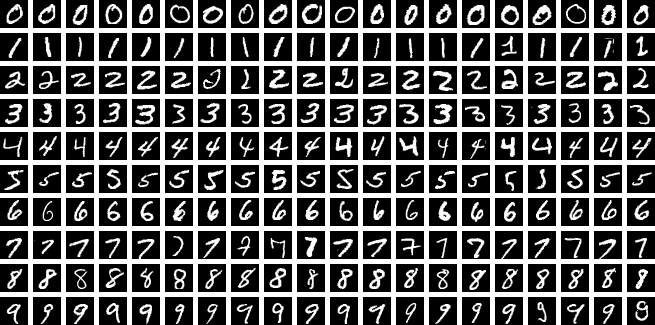

### Importing Required Libraries

In [1]:
# Import libraries
import torch
import numpy as np
from matplotlib import pyplot as plt
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
import torch.nn as nn
import torch.nn.functional as F
import time

print("All libraries are loaded")

All libraries are loaded


### Load the MNIST dataset

In [2]:
# how many samples per batch to load
batch_size = 20

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = MNIST(root = './', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.53MB/s]


In [3]:
print(len(train_data))

60000


In [4]:
train_data, val_data = torch.utils.data.random_split(train_data, [50000, 10000])

test_data = MNIST(root = './', train=False, download=True, transform=transform)

print("Training data length : ", len(train_data))
print("Validation data length : ", len(val_data))
print("Test data length : ", len(test_data))

Training data length :  50000
Validation data length :  10000
Test data length :  10000


### Data Loader

In [5]:
# Create a DataLoader for the training dataset
# DataLoader loads the dataset in batches during training
# batch_size determines how many samples are processed in one batch
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)

print("Training data created")
print("Train-Data length : ", len(train_data))


# Create a DataLoader for the validation dataset
# Validation data is used to evaluate the model during training
# It helps monitor model performance and detect overfitting
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size)

print("Validation data created")
print("Validation-Data length : ", len(val_data))


# Create a DataLoader for the test dataset
# Test data is used after training to measure the final performance of the model
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

print("Test data created")
print("Test-Data length : ", len(test_data))

Training data created
Train-Data length :  50000
Validation data created
Validation-Data length :  10000
Test data created
Test-Data length :  10000


### Visualize the dataset

Some of the training samples and their labels : 



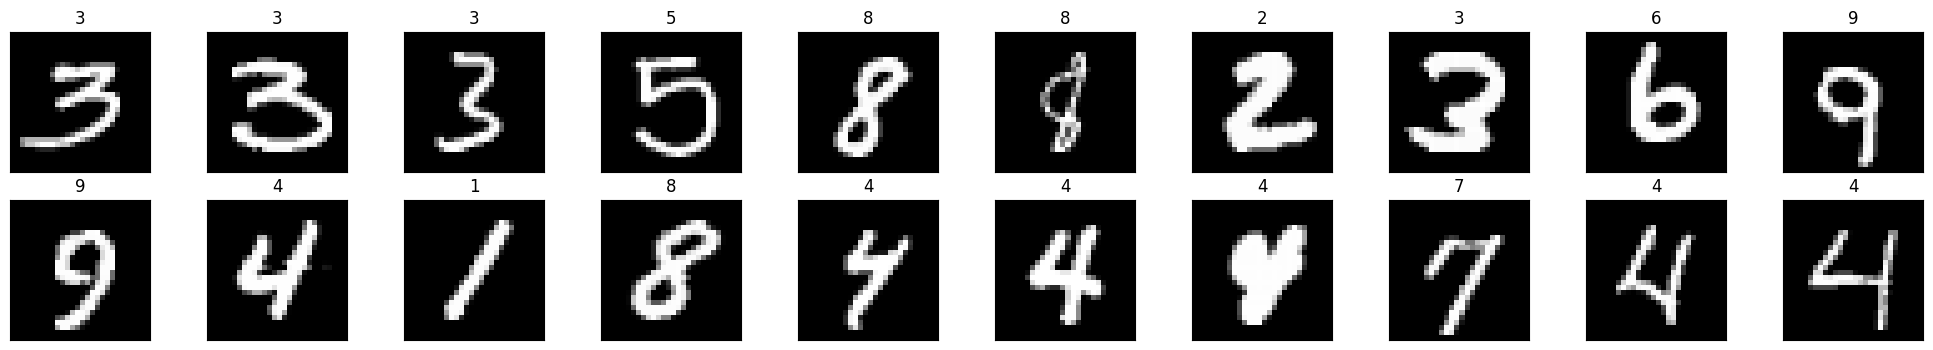

In [6]:
print("Some of the training samples and their labels : \n")

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2,int(20/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

Pixel level View of one of the training sample 




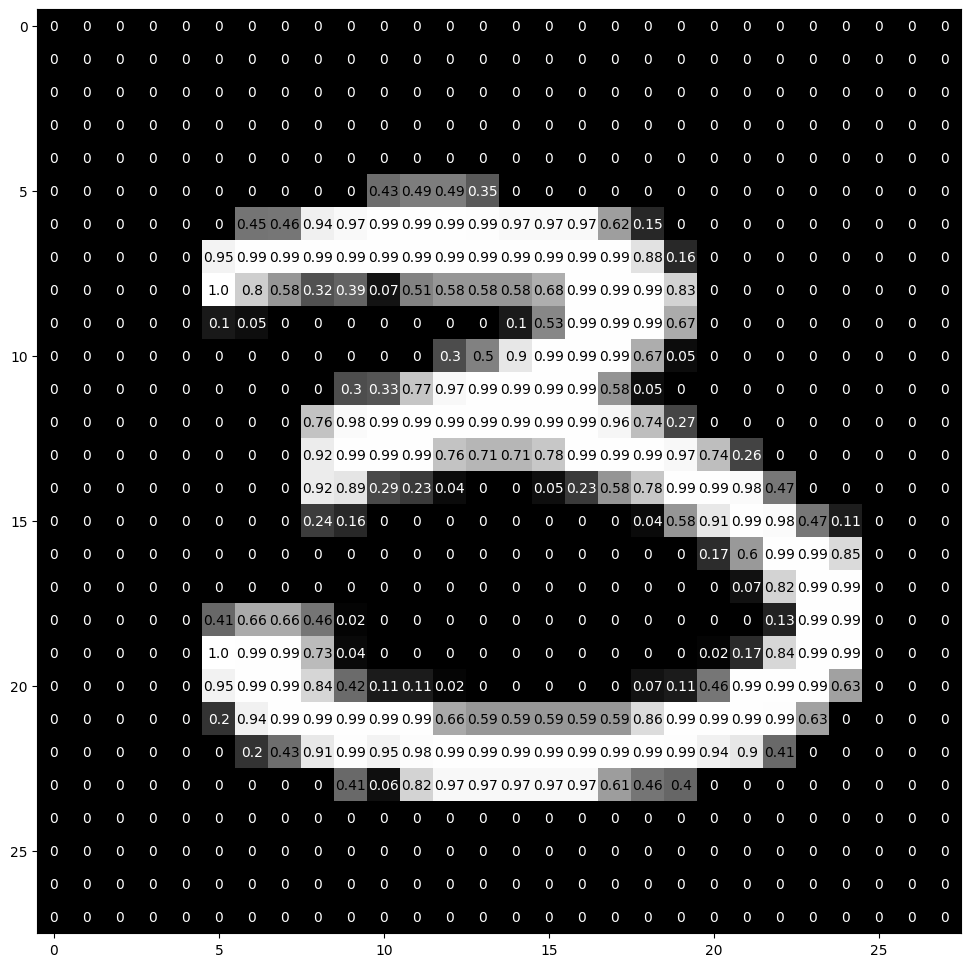

In [7]:
print ("Pixel level View of one of the training sample \n")
img = np.squeeze(images[1])
fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

print()

### **Initializing CUDA**

CUDA is used as an interface between our code and the GPU.

Normally, we run the code in the CPU. To run it in the GPU, we need CUDA. Check if CUDA is available:

In [8]:
# To test whether GPU instance is present in the system of not.
use_cuda = torch.cuda.is_available()
print('Using PyTorch version:', torch.__version__, 'CUDA:', use_cuda)

Using PyTorch version: 2.11.0+cu128 CUDA: True


If it's False, then we run the program on CPU. If it's True, then we run the program on GPU.

Let us initialize some GPU-related variables:

In [9]:
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

### **Build Model**

In [10]:
## Define the NN architecture

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 512)       # linear layer (n_hidden -> hidden_2)
        self.fc3 = nn.Linear(512, 10)        # linear layer (n_hidden -> 10)
        #self.dropout = nn.Dropout(0.2)       # dropout layer (p=0.2) # dropout prevents overfitting of data

    def forward(self, x):
        # flatten image input
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # x = F.relu(self.fc3(x)) # F.relu
        x = self.fc3(x)
        return x

# initialize the NN
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [11]:
from torchsummary import summary

In [12]:
summary(model, input_size=(1,784), batch_size=-1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]         401,920
            Linear-2                  [-1, 512]         262,656
            Linear-3                   [-1, 10]           5,130
Total params: 669,706
Trainable params: 669,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.55
Estimated Total Size (MB): 2.57
----------------------------------------------------------------


### Specify loss and optimization functions

In [13]:
## Specify loss and optimization functions

# specify loss function
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(criterion, optimizer)

CrossEntropyLoss() SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### **Train Model**

In [14]:
# number of epochs to train the model
n_epochs = 20  # suggest training between 20-50 epochs

model.train()    # prep model for training

for epoch in range(n_epochs):

    start = time.time()

    train_loss = 0.0                    # Initialize training, val loss
    val_loss=0.0

    ###################
    # Train the Model #
    ###################
    for data, target in train_loader:
        data=data.to(device)
        target=target.to(device)
        optimizer.zero_grad()            # clear the gradients of all optimized variables
        output = model(data)             # forward pass: compute predicted outputs by passing inputs to the model
        loss = criterion(output, target) # calculate the loss
        loss.backward()                  # backward pass: compute gradient of the loss with respect to model parameters
        optimizer.step()                 # perform a single optimization step (parameter update)
        train_loss += loss.item()*data.size(0)  # update running training loss

    for data, target in val_loader:
        data=data.to(device)
        target=target.to(device)
        output = model(data)                  # forward pass: compute predicted outputs by passing inputs to the model
        loss = criterion(output, target)      # calculate the loss
        val_loss += loss.item()*data.size(0)  # update running training loss

    # print training statistics
    train_loss = train_loss/len(train_loader.dataset)  # calculate average loss over an epoch"""
    val_loss = val_loss/len(val_loader.dataset)        # Validation loss

    end = time.time()
    total_time = end - start

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f} \t Time: {:.4f} sec'.format( epoch+1, train_loss, val_loss, total_time))

print("Training is done\n")

Epoch: 1 	Training Loss: 0.874862 	Validation Loss: 0.359573 	 Time: 10.3067 sec
Epoch: 2 	Training Loss: 0.326141 	Validation Loss: 0.284472 	 Time: 10.6405 sec
Epoch: 3 	Training Loss: 0.264742 	Validation Loss: 0.242103 	 Time: 10.5148 sec
Epoch: 4 	Training Loss: 0.221051 	Validation Loss: 0.209168 	 Time: 10.4201 sec
Epoch: 5 	Training Loss: 0.187292 	Validation Loss: 0.183675 	 Time: 10.4306 sec
Epoch: 6 	Training Loss: 0.161278 	Validation Loss: 0.163853 	 Time: 12.9672 sec
Epoch: 7 	Training Loss: 0.140621 	Validation Loss: 0.148430 	 Time: 10.4527 sec
Epoch: 8 	Training Loss: 0.123799 	Validation Loss: 0.135968 	 Time: 10.5308 sec
Epoch: 9 	Training Loss: 0.109931 	Validation Loss: 0.126142 	 Time: 10.0091 sec
Epoch: 10 	Training Loss: 0.098305 	Validation Loss: 0.118323 	 Time: 10.4139 sec
Epoch: 11 	Training Loss: 0.088390 	Validation Loss: 0.111763 	 Time: 10.5823 sec
Epoch: 12 	Training Loss: 0.079846 	Validation Loss: 0.106347 	 Time: 10.5259 sec
Epoch: 13 	Training Loss:

### **Test the Model**

In [15]:
# Testing the  model
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()    # prepare model for *evaluation*

for data, target in test_loader:
    data = data.to(device)
    target = target.to(device)
    output = model(data)                            # forward pass: compute predicted outputs by passing inputs to the model
    loss = criterion(output, target)                # calculate the loss
    test_loss += loss.item()*data.size(0)           # update test loss
    _, pred = torch.max(output, 1)                  # convert output probabilities to predicted class
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))        # compare predictions to true label

    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of Class label - %1s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of Class label - %1s: N/A (no training examples)' % (i))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))
print()

Test Loss: 0.076413

Test Accuracy of Class label - 0: 98% (967/980)
Test Accuracy of Class label - 1: 99% (1125/1135)
Test Accuracy of Class label - 2: 97% (1009/1032)
Test Accuracy of Class label - 3: 98% (992/1010)
Test Accuracy of Class label - 4: 97% (961/982)
Test Accuracy of Class label - 5: 96% (860/892)
Test Accuracy of Class label - 6: 97% (937/958)
Test Accuracy of Class label - 7: 97% (1002/1028)
Test Accuracy of Class label - 8: 95% (928/974)
Test Accuracy of Class label - 9: 96% (976/1009)

Test Accuracy (Overall): 97% (9757/10000)



Test Images and their predicted labels : 



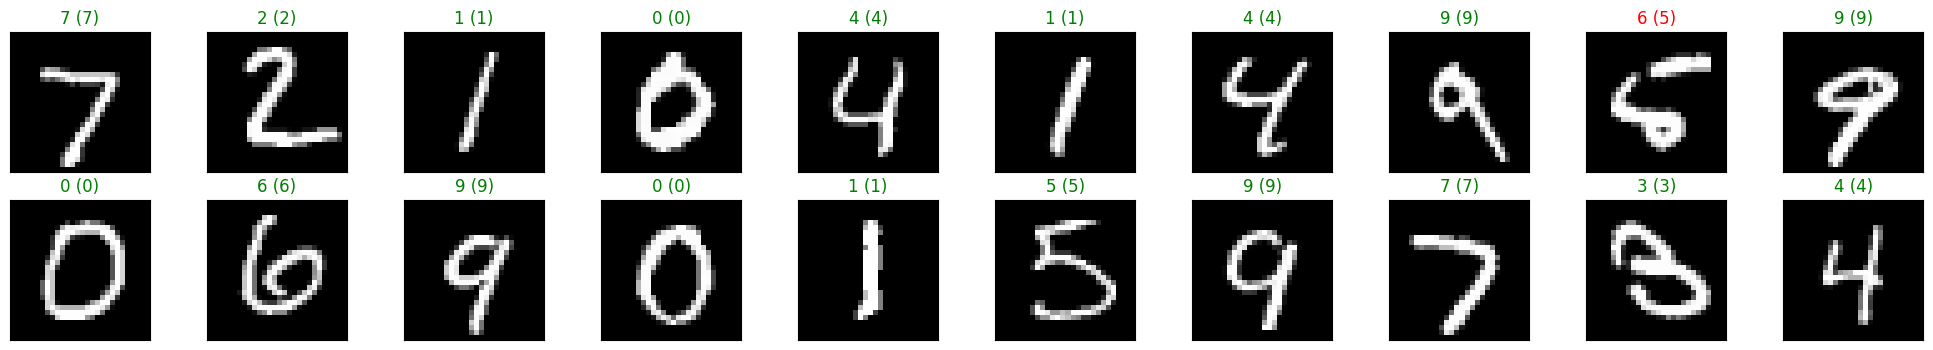

In [16]:
# obtain one batch of test images

print("Test Images and their predicted labels : \n")

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# get sample outputs
output = model(images)

_, preds = torch.max(output, 1)  # convert output probabilities to predicted class
images = images.cpu()        # prep images for display

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

---

<center>
$END$
</center>

---